# Comparying ASC through transects

As a sanity check of changes, and because this way we can also see changes in teh vertical structure of ASC

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean as cm
import glob
import matplotlib.colors as col
import cf_xarray as cf

import cv2
import warnings
import logging
from scipy.ndimage import distance_transform_edt
import scipy.ndimage as nd
from scipy.interpolate import griddata

logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

figdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [2]:
client = Client(threads_per_worker = 1)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

In [4]:
#in this definition, no frequency can be used only for static data
catalog = intake.cat.access_nri
def importer(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0):
    warnings.filterwarnings('ignore')
    var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

In [4]:
#lets try first with calcualted speeds at surface
start_date='2000-01'
end_date = '2000-12'

In [5]:
%%time
#Us
Us_0025  = importer("panant-0025-zstar-ACCESSyr2",catalog,"uo",frequency='1mon',start_time=start_date,end_time=end_date).mean('time').compute()
Us_005  = importer("panant-005-zstar-ACCESSyr2",catalog,"uo",frequency='1mon',start_time=start_date,end_time=end_date).mean('time').compute()
Us_01  = importer("panant-01-zstar-ACCESSyr2",catalog,"uo",frequency='1mon',start_time=start_date,end_time=end_date).mean('time').compute()

2025-11-17 14:31:16,409 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 24.61 GiB -- Worker memory limit: 30.62 GiB
2025-11-17 14:31:21,720 - distributed.worker.memory - WARNING - Worker is at 79% memory usage. Resuming worker. Process memory: 24.43 GiB -- Worker memory limit: 30.62 GiB


CPU times: user 5min 25s, sys: 1min 21s, total: 6min 47s
Wall time: 7min 22s


In [6]:
%%time
#interpolating to the see differences
Us_01_on0025 = Us_01.interp(xq=Us_0025.xq,yh=Us_0025.yh)
Us_005_on0025 = Us_005.interp(xq=Us_0025.xq,yh=Us_0025.yh)

CPU times: user 4min 46s, sys: 4min 25s, total: 9min 11s
Wall time: 6min 20s


### Exemplary Fresh Regime

In [10]:
#seeint the longitudes
lon_fresh =  -260
lon_dense =  -40
lon_warm =  -110

Text(0.5, 1.0, 'Transect locations')

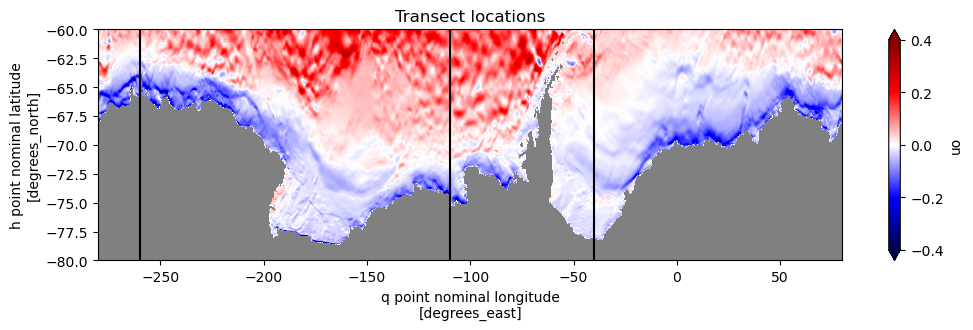

In [12]:
plt.figure(figsize=(12,3))
ax0 = plt.subplot(1,1,1)
Us_01.isel(z_l=0).plot(vmin=-0.4,vmax=0.4,cmap='seismic')
plt.plot([lon_fresh ,lon_fresh],[-80,-60],color='k')
plt.plot([lon_dense ,lon_dense],[-80,-60],color='k')
plt.plot([lon_warm ,lon_warm],[-80,-60],color='k')
ax0.set_facecolor('grey') 
plt.ylim(-80,-60)
plt.title('Transect locations')

All future three transects

(-80.0, -60.0)

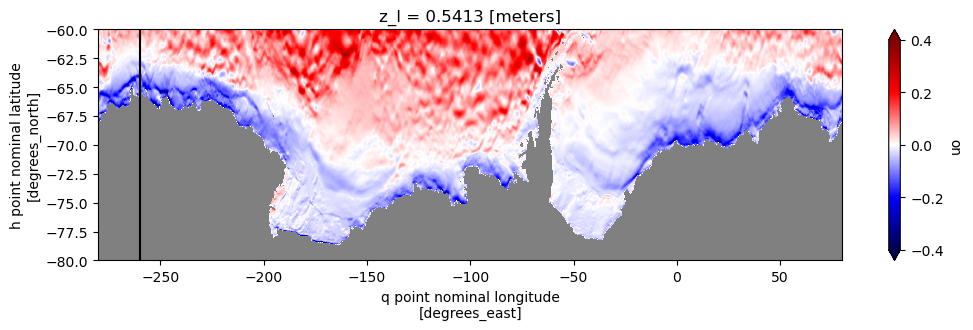

In [9]:

plt.figure(figsize=(12,3))
ax0 = plt.subplot(1,1,1)
Us_01.isel(z_l=0).plot(vmin=-0.4,vmax=0.4,cmap='seismic')
plt.plot([lon_fresh ,lon_fresh],[-80,-60],color='k')
ax0.set_facecolor('grey') 
plt.ylim(-80,-60)

Original plots, not anomalies

Text(0.5, 1.0, '[c] Panan0025, Fresh regime, $260^o W$')

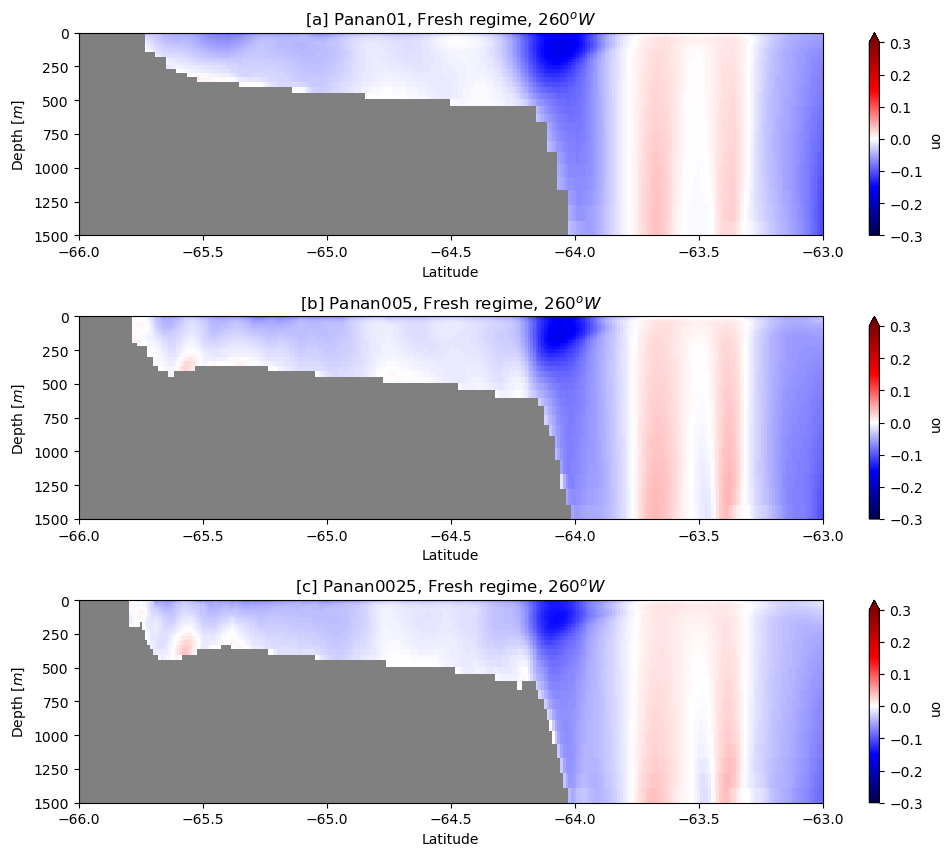

In [39]:
plt.figure(figsize=(12,10))
plt.subplots_adjust(hspace=0.4)


ax0 = plt.subplot(3,1,1)
Us_01_on0025.sel(xq = lon_fresh,method='nearest').plot(x='yh',vmin=-0.3,vmax=0.3,cmap='seismic')
ax0.set_facecolor('grey') 

plt.xlim(-66,-63)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[a] Panan01, Fresh regime, $260^o W$')

ax1 = plt.subplot(3,1,2)
Us_005_on0025.sel(xq = lon_fresh,method='nearest').plot(x='yh',vmin=-0.3,vmax=0.3,cmap='seismic')
ax1.set_facecolor('grey') 
plt.xlim(-66,-63)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[b] Panan005, Fresh regime, $260^o W$')


ax2 = plt.subplot(3,1,3)
Us_0025.sel(xq = lon_fresh,method='nearest').plot(x='yh',vmin=-0.3,vmax=0.3,cmap='seismic')
ax2.set_facecolor('grey') 

plt.xlim(-66,-63)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[c] Panan0025, Fresh regime, $260^o W$')

In $260^o W$ velocities do seem to get weaker at surface with resolution, as suggested by the previous analysis along the 1000m isobath. The core seem to move to shallower depths too, which suggests isopycnals might be getting a little flatter near the bottom of the slope

### Exemplary Dense Regime

In [51]:
#seeint the longitudes
lon_dense =  -40

(-80.0, -60.0)

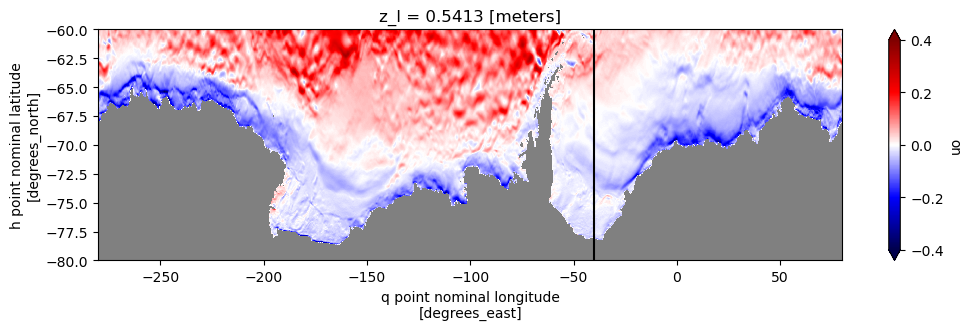

In [52]:
plt.figure(figsize=(12,3))
ax0 = plt.subplot(1,1,1)
Us_01.isel(z_l=0).plot(vmin=-0.4,vmax=0.4,cmap='seismic')
plt.plot([lon_dense ,lon_dense],[-80,-60],color='k')
ax0.set_facecolor('grey') 
plt.ylim(-80,-60)

Exemplary dense regime

Text(0.5, 1.0, '[c] Panan0025, Dense regime, $40^o W$')

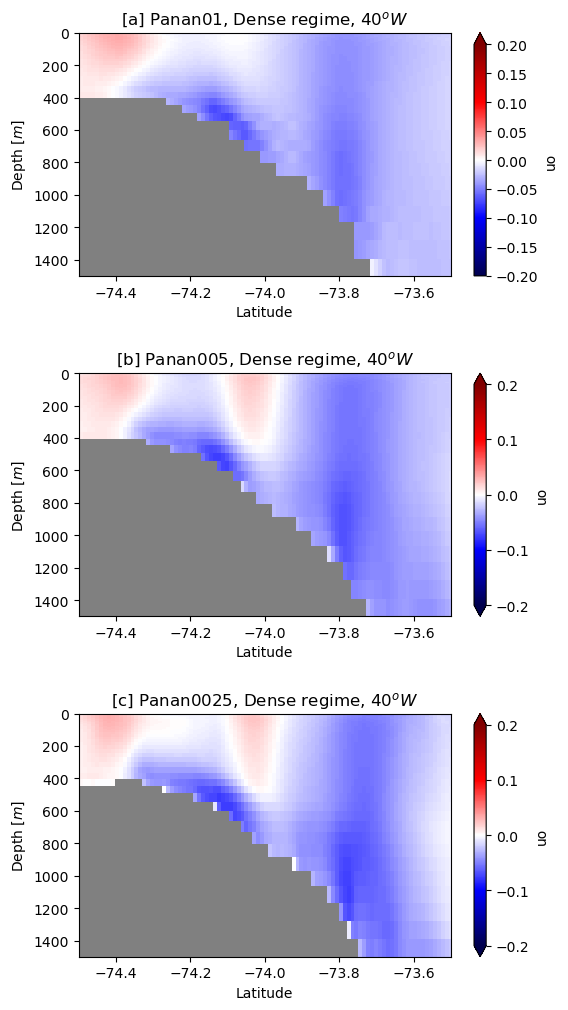

In [62]:
plt.figure(figsize=(6,12))
plt.subplots_adjust(hspace=0.4)


ax0 = plt.subplot(3,1,1)
Us_01_on0025.sel(xq = lon_dense,method='nearest').plot(x='yh',vmin=-0.2,vmax=0.2,cmap='seismic')
ax0.set_facecolor('grey') 

plt.xlim(-74.5,-73.5)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[a] Panan01, Dense regime, $40^o W$')

ax1 = plt.subplot(3,1,2)
Us_005_on0025.sel(xq = lon_dense,method='nearest').plot(x='yh',vmin=-0.2,vmax=0.2,cmap='seismic')
ax1.set_facecolor('grey') 
plt.xlim(-74.5,-73.5)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[b] Panan005, Dense regime, $40^o W$')


ax2 = plt.subplot(3,1,3)
Us_0025.sel(xq = lon_dense,method='nearest').plot(x='yh',vmin=-0.2,vmax=0.2,cmap='seismic')
ax2.set_facecolor('grey') 

plt.xlim(-74.5,-73.5)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[c] Panan0025, Dense regime, $40^o W$')

In this one it seems like bottom intensification gets a little stronger with resolution. WHich makes sense in light of stronger overflows

### Exemplary warm Regime

In [66]:
#seeint the longitudes
lon_warm =  -110

(-80.0, -60.0)

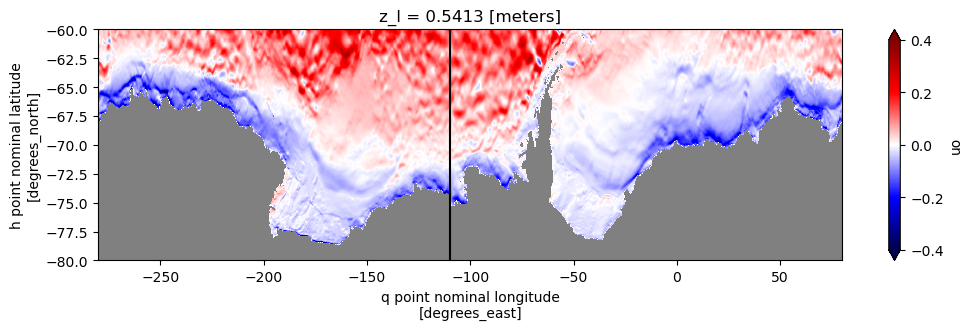

In [67]:
plt.figure(figsize=(12,3))
ax0 = plt.subplot(1,1,1)
Us_01.isel(z_l=0).plot(vmin=-0.4,vmax=0.4,cmap='seismic')
plt.plot([lon_warm ,lon_warm],[-80,-60],color='k')
ax0.set_facecolor('grey') 
plt.ylim(-80,-60)

Text(0.5, 1.0, '[c] Panan0025, Warm regime, $110^o W$')

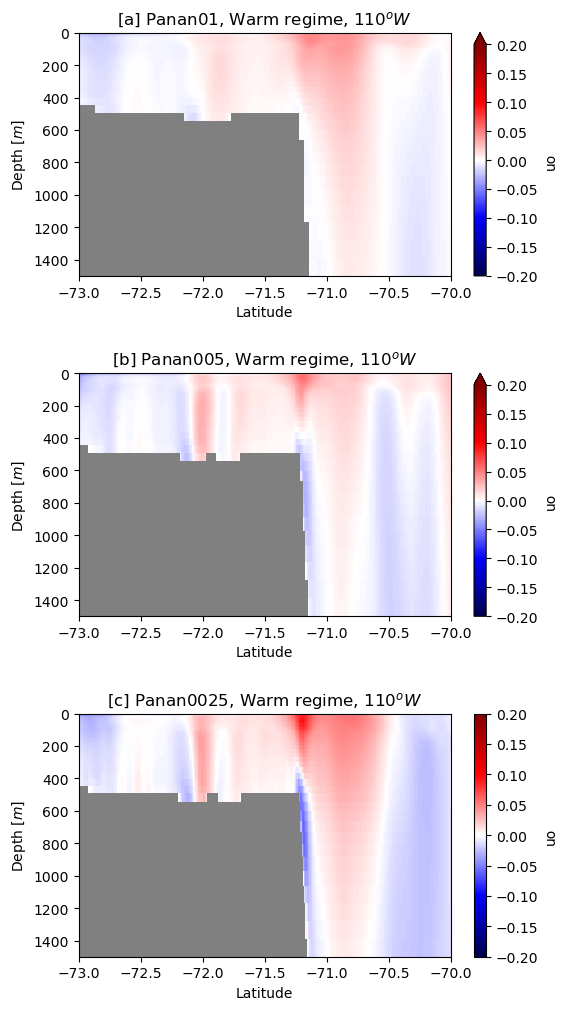

In [69]:
plt.figure(figsize=(6,12))
plt.subplots_adjust(hspace=0.4)


ax0 = plt.subplot(3,1,1)
Us_01_on0025.sel(xq = lon_warm,method='nearest').plot(x='yh',vmin=-0.2,vmax=0.2,cmap='seismic')
ax0.set_facecolor('grey') 

plt.xlim(-73,-70)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[a] Panan01, Warm regime, $110^o W$')

ax1 = plt.subplot(3,1,2)
Us_005_on0025.sel(xq = lon_warm,method='nearest').plot(x='yh',vmin=-0.2,vmax=0.2,cmap='seismic')
ax1.set_facecolor('grey') 
plt.xlim(-73,-70)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[b] Panan005, Warm regime, $110^o W$')


ax2 = plt.subplot(3,1,3)
Us_0025.sel(xq = lon_warm,method='nearest').plot(x='yh',vmin=-0.2,vmax=0.2,cmap='seismic')
ax2.set_facecolor('grey') 

plt.xlim(-73,-70)
plt.ylim(1500,0)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Latitude')
plt.title(r'[c] Panan0025, Warm regime, $110^o W$')

Interesting here! We see a strentghening of the eastward ASC at the surface, and a appearance and strengthening of a westward undercurrent!

### Summary

Transect view seem to confirm some slowdown of the ASC in fresh regimes, but also ASC core seems to get shalower. In warm regimes, the increased resolution seem to favor the appearance of an undercurrent, and interesting finding, that on the averages of along-isobath is shown as a decrease in mean(z) speed. Finally dense regimes get more bottom intensified.  Id say increasing the resolution sort of enhance the inherent characteristics of regional ASC!

It is interesting to me that the undercurrent appears when we go to higher resolutions! Especially cause a lot of studies sugggest that we need ice shelf melting to represent that!

### Along isobath average changes

It might be useful to an average within the different regime locations, and present plots in along-isobath space, to see if these changes are consistent within different regions with the same regime, or if they are isolated

In [71]:
#Importing Wilma's regimes
file_path = '/g/data/x77/wgh581/Post_Process/access-om2/ASC_regimes_01deg_jra55v13_ryf9091_plt_approach_smoothed_btm200m_50.npz'
ASC_regimes_all = np.load(file_path)
ASC_regimes = ASC_regimes_all['ASC_regimes_annual']
#ASC_regimes_monthly = ASC_regimes_all['ASC_regimes_monthly']
ASC_regimes_2d = np.vstack((ASC_regimes, ASC_regimes))

In [75]:
data_path = '/g/data/x77/wgh581/Post_Process/access-om2/'
file_name = 'Antarctic_slope_contour_1km_velocities_plt_approach.npz'

data = np.load(data_path + file_name)
distance_along_contour = data['distance_along_contour']
lon_along_contour = data['lon_along_contour']

In [74]:
import matplotlib
colorsList_no4 = [('lightgreen'),('blueviolet'),('tomato'),('c')]
CustomCmap_no4 = matplotlib.colors.ListedColormap(colorsList_no4)
colorsList_no3 = [('lightgreen'),('blueviolet'),('tomato')]
CustomCmap_no3 = matplotlib.colors.ListedColormap(colorsList_no3)

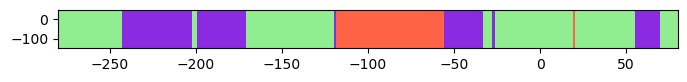

In [93]:
#sanity test
plt.figure(figsize=(8,0.5))
plt.pcolormesh(lon_along_contour[:-1], [0,-100], ASC_regimes_2d[:,:-1], cmap=CustomCmap_no3)

creating xarray for interpolation into new grid

In [139]:
ASC_regimes_XR = xr.DataArray(data=ASC_regimes_2d[1,:-1],dims='xq')#
ASC_regimes_XR['xq'] = lon_along_contour[:-1]
ASC_regimes_XR_panan0025 = ASC_regimes_XR.drop_duplicates('xq').interp(xq=Us_01_on0025.xq)
ASC_regimes_XR_panan005 = ASC_regimes_XR.drop_duplicates('xq').interp(xq=Us_005.xq)
ASC_regimes_XR_panan01 = ASC_regimes_XR.drop_duplicates('xq').interp(xq=Us_01.xq)

(-280.0, 80.0)

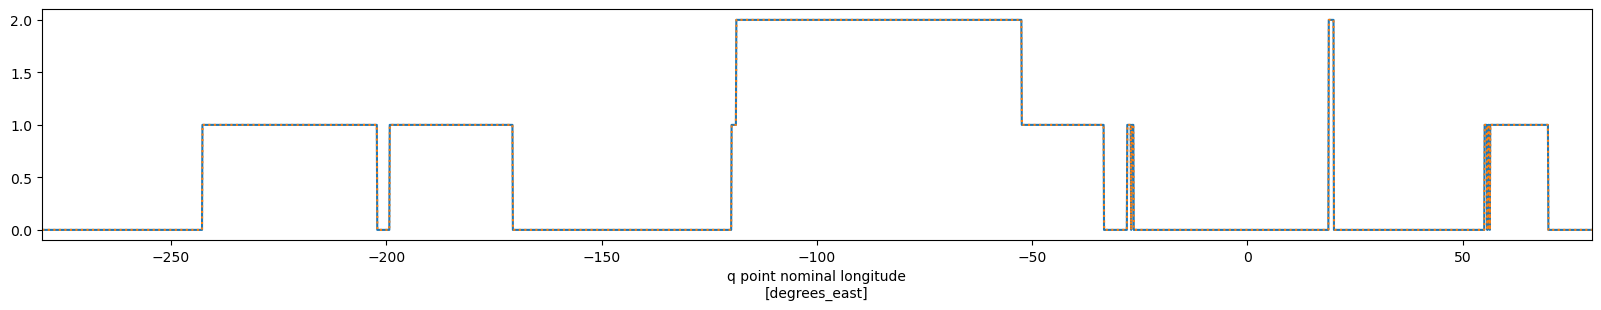

In [138]:
#sanity check
plt.figure(figsize=(20,3))
ASC_regimes_XR.drop_duplicates('xq').plot()
ASC_regimes_XR_panan0025.plot(linestyle=':',label='0.025')
plt.xlim(-280,80)

convert latitude to isobath coordinates using xhistogram

In [149]:
#importing areas
area_0025  = importer("panant-0025-zstar-ACCESSyr2",catalog,"areacello_cu",frequency='fx',).compute()
area_005  = importer("panant-005-zstar-ACCESSyr2",catalog,"areacello_cu",frequency='fx').compute()
area_01  = importer("panant-01-zstar-ACCESSyr2",catalog,"areacello_cu",frequency='fx').compute()
#importing depth
deptho_0025  = importer("panant-0025-zstar-ACCESSyr2",catalog,"deptho",frequency='fx',).interp(xh=area_0025.xq).compute()
deptho_005  = importer("panant-005-zstar-ACCESSyr2",catalog,"deptho",frequency='fx').interp(xh=area_005.xq).compute()
deptho_01  = importer("panant-01-zstar-ACCESSyr2",catalog,"deptho",frequency='fx').interp(xh=area_01.xq).compute()

In [143]:
from xhistogram.xarray import histogram

In [215]:
#isobaths for visuals
Panan01_isobaths = xr.open_dataset('/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Panan01_slope_coordinate_system_650mto2000m.nc')
Panan005_isobaths = xr.open_dataset('/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Panan005_slope_coordinate_system_650mto2000m.nc')
Panan0025_isobaths = xr.open_dataset('/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Panan0025_slope_coordinate_system_650mto2000m.nc')


In [222]:
Mask_01 = Panan01_isobaths.Mask.interp(yq=deptho_01.yh).bfill('yh')
Mask_005 = Panan005_isobaths.Mask.interp(yq=deptho_005.yh).bfill('yh')
Mask_0025 = Panan0025_isobaths.Mask.interp(yq=deptho_0025.yh).bfill('yh')

In [387]:
isobath_bins=np.linspace(0,2000,200)
lat_slice = slice(-88,-60)


#### Us01
#masking arrays
Us01_masked = (Us_01*Mask_01).rename('U').sel(yh=lat_slice)
deptho_01_masked = (deptho_01*Mask_01).rename('deptho').sel(yh=lat_slice)
area_01_masked = (area_01*Mask_01).rename('Area').sel(yh=lat_slice)
# # #binning 
U01_iso = (histogram(deptho_01_masked,bins=isobath_bins,dim=['yh'],weights= (Us01_masked  *area_01_masked) )/\
histogram(deptho_01_masked,bins=isobath_bins,dim=['yh'],weights=area_01_masked)).interpolate_na('deptho_bin')
U01_iso['z_l'] = Us_01.z_l



#### Us005
#masking arrays
Us005_masked = (Us_005*Mask_005).rename('U').sel(yh=lat_slice)
deptho_005_masked = (deptho_005*Mask_005).rename('deptho').sel(yh=lat_slice)
area_005_masked = (area_005*Mask_005).rename('Area').sel(yh=lat_slice)
# # #binning 
U005_iso = (histogram(deptho_005_masked,bins=isobath_bins,dim=['yh'],weights= (Us005_masked  *area_005_masked) )/\
histogram(deptho_005_masked,bins=isobath_bins,dim=['yh'],weights=area_005_masked)).interpolate_na('deptho_bin')
U005_iso['z_l'] = Us_005.z_l


#### Us005
#masking arrays
Us0025_masked = (Us_0025*Mask_0025).rename('U').sel(yh=lat_slice)
deptho_0025_masked = (deptho_0025*Mask_0025).rename('deptho').sel(yh=lat_slice)
area_0025_masked = (area_0025*Mask_0025).rename('Area').sel(yh=lat_slice)
# # #binning 
U0025_iso = (histogram(deptho_0025_masked,bins=isobath_bins,dim=['yh'],weights= (Us0025_masked  *area_0025_masked) )/\
histogram(deptho_0025_masked,bins=isobath_bins,dim=['yh'],weights=area_0025_masked)).interpolate_na('deptho_bin')
U0025_iso['z_l'] = Us_0025.z_l


In [388]:
U01_iso.name='U'
U005_iso.name='U'
U0025_iso.name='U'

Sanity check

(0.0, 1500.0)

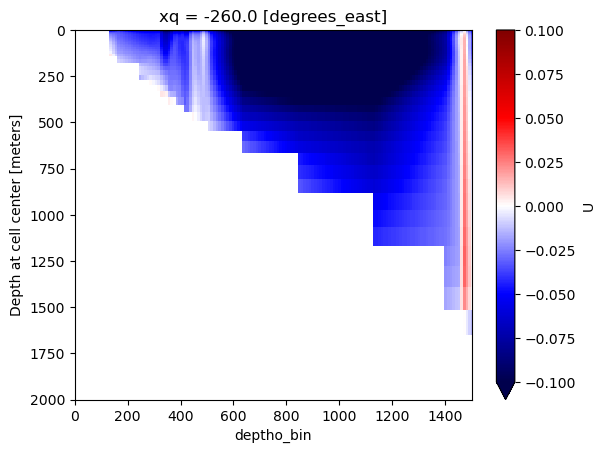

In [389]:
U01_iso.sel(xq = lon_fresh,method='nearest').plot(x='deptho_bin',vmin=-0.1,vmax=0.1,cmap='seismic')
plt.ylim(2000,0)
plt.xlim(0,1500)

mhmm, that might not work cause this approach seem to clean up somehow the bottom intensification

Averaging within regimes

In [390]:
##### with original data 
#masks for fresh regimes
fresh_01 = (1 + (ASC_regimes_XR_panan01.where(ASC_regimes_XR_panan01==0) *0 )).fillna(0)
fresh_005 = (1 + (ASC_regimes_XR_panan005.where(ASC_regimes_XR_panan005==0) *0 )).fillna(0)
fresh_0025 = (1 + (ASC_regimes_XR_panan0025.where(ASC_regimes_XR_panan0025==0) *0 )).fillna(0)
#means for fresh regimes
U01_iso_fresh = U01_iso.where(fresh_01==1).mean('xq')
U005_iso_fresh = U005_iso.where(fresh_005==1).mean('xq')
U0025_iso_fresh = U0025_iso.where(fresh_0025==1).mean('xq')


In [391]:
#masks for dense regimes
dense_01 = (1 + (ASC_regimes_XR_panan01.where(ASC_regimes_XR_panan01==1) *0 )).fillna(0)
dense_005 = (1 + (ASC_regimes_XR_panan005.where(ASC_regimes_XR_panan005==1) *0 )).fillna(0)
dense_0025 = (1 + (ASC_regimes_XR_panan0025.where(ASC_regimes_XR_panan0025==1) *0 )).fillna(0)
#means for dense regimes
U01_iso_dense = U01_iso.where(dense_01==1).mean('xq')
U005_iso_dense = U005_iso.where(dense_005==1).mean('xq')
U0025_iso_dense = U0025_iso.where(dense_0025==1).mean('xq')

In [392]:
#masks for warm regimes
warm_01 = (1 + (ASC_regimes_XR_panan01.where(ASC_regimes_XR_panan01==2) *0 )).fillna(0)
warm_005 = (1 + (ASC_regimes_XR_panan005.where(ASC_regimes_XR_panan005==2) *0 )).fillna(0)
warm_0025 = (1 + (ASC_regimes_XR_panan0025.where(ASC_regimes_XR_panan0025==2) *0 )).fillna(0)
#means for dense regimes
U01_iso_warm = U01_iso.where(warm_01==1).mean('xq')
U005_iso_warm = U005_iso.where(warm_005==1).mean('xq')
U0025_iso_warm = U0025_iso.where(warm_0025==1).mean('xq')

(0.0, 1500.0)

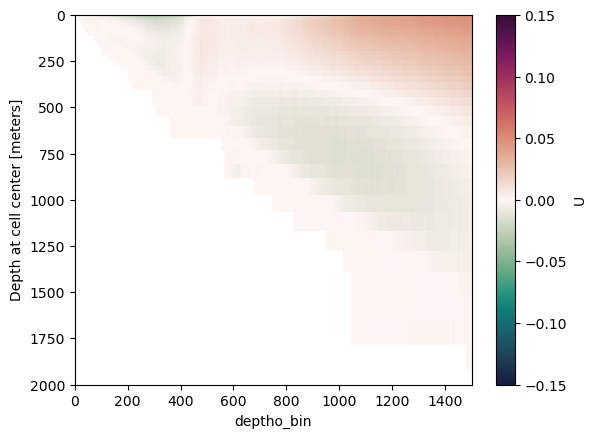

In [393]:
#sanity check
U0025_iso_warm.plot(x='deptho_bin',vmin=-0.15,vmax=0.15,cmap=cm.cm.curl)
plt.ylim(2000,0)
plt.xlim(0,1500)

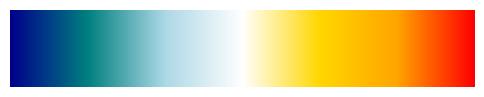

In [394]:
from matplotlib.colors import LinearSegmentedColormap

# Define your custom diverging colormap
colors = [
    ("darkblue"),     # strong negative
    ("teal"),         # moderate negative
    ("lightblue"),    # weak negative
    ("white"),        # center
    ("gold"),       # weak positive
    ("orange"),       # moderate positive
    ("red")           # strong positive
]

my_cmap = LinearSegmentedColormap.from_list("white_center_diverging", colors)

# Example: plot a colorbar to visualize it
plt.figure(figsize=(6,1))
plt.imshow([range(256)], cmap=my_cmap, aspect='auto')
plt.gca().set_axis_off()
plt.show()

Text(0.5, 1.0, '[i] Panan0025, Dense regime')

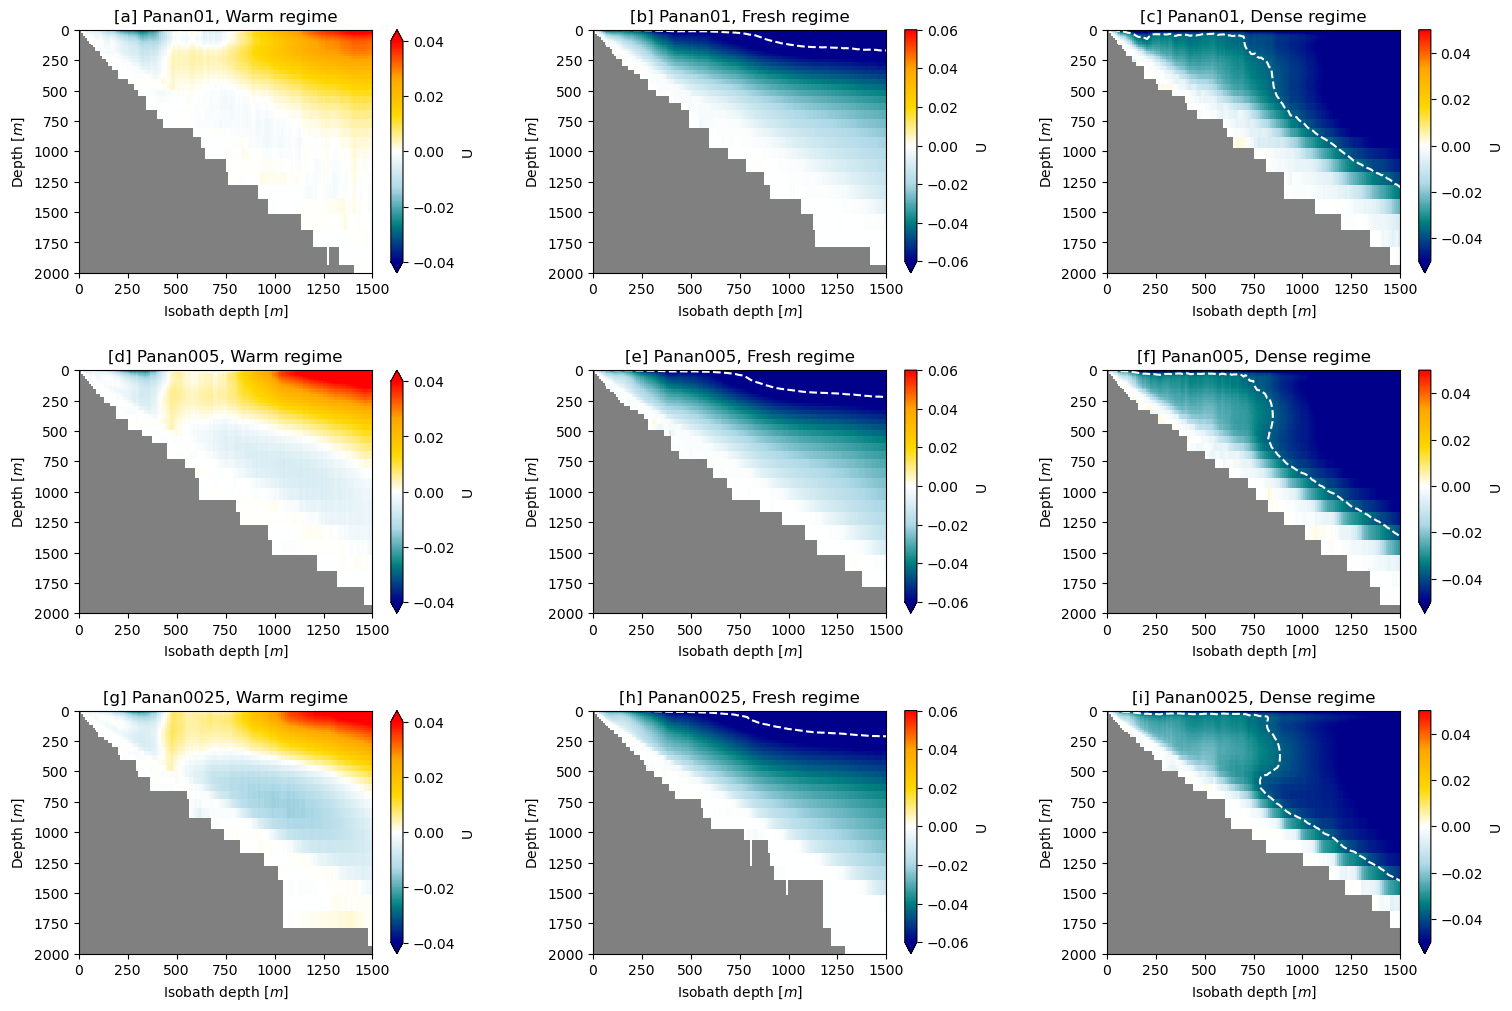

In [415]:
plt.figure(figsize=(18,12))
plt.subplots_adjust(hspace=0.4,wspace=0.4)
cmap_choice = my_cmap#cm.cm.balance

#####      Part 1  - warm regimes !#################
ax0 = plt.subplot(3,3,1)
U01_iso_warm.plot(x='deptho_bin',vmin=-0.04,vmax=0.04,cmap=cmap_choice)
ax0.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[a] Panan01, Warm regime')


ax1 = plt.subplot(3,3,4)
U005_iso_warm.plot(x='deptho_bin',vmin=-0.04,vmax=0.04,cmap=cmap_choice)
ax1.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[d] Panan005, Warm regime')

ax2 = plt.subplot(3,3,7)
U0025_iso_warm.plot(x='deptho_bin',vmin=-0.04,vmax=0.04,cmap=cmap_choice)
ax2.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[g] Panan0025, Warm regime')



#####      Part 2  - Fresh regimes !#################
ax3 = plt.subplot(3,3,2)
U01_iso_fresh.plot(x='deptho_bin',vmin=-0.06,vmax=0.06,cmap=cmap_choice)
U01_iso_fresh.plot.contour(x='deptho_bin',levels=[-0.07,],colors='w')
ax3.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[b] Panan01, Fresh regime')



ax4 = plt.subplot(3,3,5)
U005_iso_fresh.plot(x='deptho_bin',vmin=-0.06,vmax=0.06,cmap=cmap_choice)
U005_iso_fresh.plot.contour(x='deptho_bin',levels=[-0.07,],colors='w')
ax4.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[e] Panan005, Fresh regime')


ax5 = plt.subplot(3,3,8)
U0025_iso_fresh.plot(x='deptho_bin',vmin=-0.06,vmax=0.06,cmap=cmap_choice)
U0025_iso_fresh.plot.contour(x='deptho_bin',levels=[-0.07,],colors='w')
ax5.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[h] Panan0025, Fresh regime')




#####      Part 3  - Dense regimes !#################

ax6 = plt.subplot(3,3,3)
U01_iso_dense.plot(x='deptho_bin',vmin=-0.05,vmax=0.05,cmap=cmap_choice)
U01_iso_dense.plot.contour(x='deptho_bin',levels=[-0.037,],colors='w')
ax6.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[c] Panan01, Dense regime')



ax6 = plt.subplot(3,3,6)
U005_iso_dense.plot(x='deptho_bin',vmin=-0.05,vmax=0.05,cmap=cmap_choice)
U005_iso_dense.plot.contour(x='deptho_bin',levels=[-0.037,],colors='w')
ax6.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[f] Panan005, Dense regime')


ax7 = plt.subplot(3,3,9)
U0025_iso_dense.plot(x='deptho_bin',vmin=-0.05,vmax=0.05,cmap=cmap_choice)
U0025_iso_dense.plot.contour(x='deptho_bin',levels=[-0.037,],colors='w')
ax7.set_facecolor('grey') 

plt.ylim(2000,0)
plt.xlim(0,1500)
plt.ylabel(r'Depth [$m$]')
plt.xlabel(r'Isobath depth [$m$]')
plt.title(r'[i] Panan0025, Dense regime')





Interesting - the warm regime signal is very clear even when averaging large areas. THe fresh regime signal is opposite than what we find in the signle transect, but rather consistent across resolutions. the dense regime singal also seem consistent with transect, but we dont seem to find a slowdown

**try and redo those using the interpolated data into the same 0.025 resolution, to make possible to do anomalies**